# Exploratory Analysis & Parameter Testing

Initial experimental notebook dedicated to testing and validating baseline configurations for the YOLOv8n-seg architecture, establishing the foundational hyperparameters for subsequent development.

## Introduction

Thermal images downloaded from Roboflow dataset. 

- First model that is going to be tested : YOLOv8-seg (nano)
- What we want : Instance Segmentation - This method treats each object as a unique entity. It detects individual instances and assigns a unique label to the pixels of each one. 
- Then maybe also test this model : YOLO26n-seg

In [12]:
from ultralytics import YOLO
from ultralytics.data.converter import convert_coco
import matplotlib.pyplot as plt
import pandas as pd
import os
import random
import cv2
import numpy as np
import zipfile

### First training yolov8n-seg with Binary Dataset (F)
Dataset already in the good format from Roboflow downloading (no need of conversion)

In [3]:
zip_file = "./F_Binary_Dataset.zip"
new_name = "F_Binary_Dataset"

# Extract
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(new_name)

print(f"Extracted to {new_name}")

Extracted to F_Binary_Dataset


In [2]:
# repartition of the images in the dataset
dataset_path = "./F_Binary_Dataset"

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(dataset_path, split, "images")
    print(split, "images:", len(os.listdir(img_dir)))

train images: 411
valid images: 127
test images: 95


In [3]:
# download the model
baseline = YOLO("yolov8n-seg.pt")

In [ ]:
# train the model on our dataset
results = baseline.train(
    data="./F_Binary_Dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    workers=4,
    name="baseline_yolov8n"
)

New https://pypi.org/project/ultralytics/8.4.59 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./F_Binary_Dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, n

### Best baseline yolov8n-seg model 

In [4]:
# Save best weights
best_baseline = YOLO("./runs/segment/baseline_yolov8n/weights/best.pt")

In [10]:
# Evaluate on the test dataset
metrics_test = best_baseline.val(
    data="./F_Binary_Dataset/data.yaml",
    split="test",
    verbose=True,
    plots=True
)

p  = metrics_test.seg.p.mean()
r  = metrics_test.seg.r.mean()
f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

print("\n" + "=" * 60)
print("BASELINE Yolov8n-seg Metrics on Test Set:")
print("=" * 60)
print(f"mAP50        (Box):  {metrics_test.box.map50:.4f}")
print(f"mAP50-95     (Box):  {metrics_test.box.map:.4f}")
print(f"mAP50        (Mask): {metrics_test.seg.map50:.4f}")
print(f"mAP50-95     (Mask): {metrics_test.seg.map:.4f}")
print(f"Recall       (Mask): {r:.4f}")
print(f"Precision    (Mask): {p:.4f}")
print(f"F1           (Mask): {f1:.4f}")
print("=" * 60)

Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 972.6±326.4 MB/s, size: 12.3 KB)
val: Scanning /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/labels.cache... 95 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 95/95 28.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.7it/s 3.5s0.4s
                   all         95        297      0.822      0.778      0.838       0.62      0.822      0.778      0.838       0.55
Speed: 3.3ms preprocess, 1.6ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to /home/floreM/FlukePrint_YOLO/Gihub_final/runs/segment/val3

BASELINE Yolov8n-seg Metrics on Test Set:
mAP50        (Box):  0.8381
mAP50-95     (Box):  0.6199

Prediction visualization

In [5]:
images_path = "./F_Binary_Dataset/test/images"
labels_path = "./F_Binary_Dataset/test/labels"

image_files = [f for f in os.listdir(images_path) if f.endswith(".jpg")]

In [6]:
def draw_ground_truth(img, label_path):

    h, w, _ = img.shape

    if os.path.exists(label_path):

        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:

            values = list(map(float, line.strip().split()))
            polygon = values[1:]

            polygon = np.array(polygon).reshape(-1,2)

            polygon[:,0] *= w
            polygon[:,1] *= h

            polygon = polygon.astype(np.int32)

            cv2.polylines(img, [polygon], True, (255,0,0), 2)

    return img

In [13]:
# Predict on the test dataset
predictions = best_baseline.predict(
    source="./F_Binary_Dataset/test/images",
    save=True,
)


image 1/95 /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/images/video_001_event3_A001_500_t-00000s_01_jpg.rf.a1c72ee891d1f439c9979daf20d664d7.jpg: 640x640 1 flukeprints, 4.2ms
image 2/95 /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/images/video_001_event3_A001_620_t-00120s_jpg.rf.a4f767ad4c3564bf2b0793cccda1c348.jpg: 640x640 1 flukeprints, 4.6ms
image 3/95 /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/images/video_026_event1_A015_500_t-00000s_04_jpg.rf.0b35c4347090497620246541fc73f63e.jpg: 640x640 2 flukeprintss, 4.4ms
image 4/95 /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/images/video_026_event1_A015_500_t-00000s_05_jpg.rf.dc896da39b0168755ae64bf12c7c5366.jpg: 640x640 2 flukeprintss, 4.4ms
image 5/95 /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/images/video_030_event10_A018_500_t-00000s_01_jpg.rf.bfcedb7fff2a590cd37ec2ea512900f0.jpg: 640x640 7 flukeprintss, 4.4ms
image 6/95 /home/floreM/FlukePrin

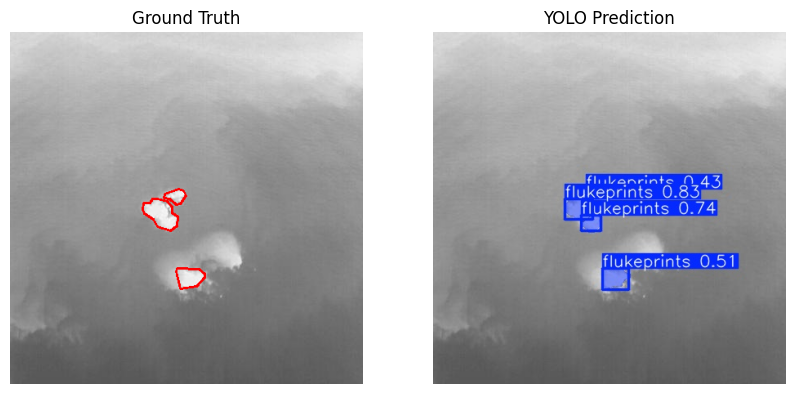

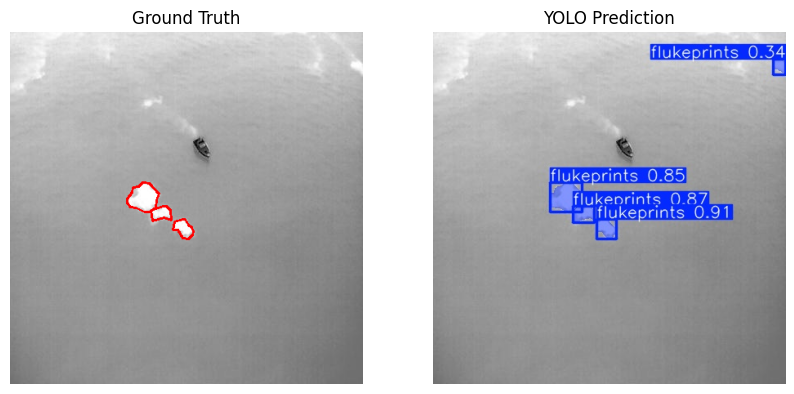

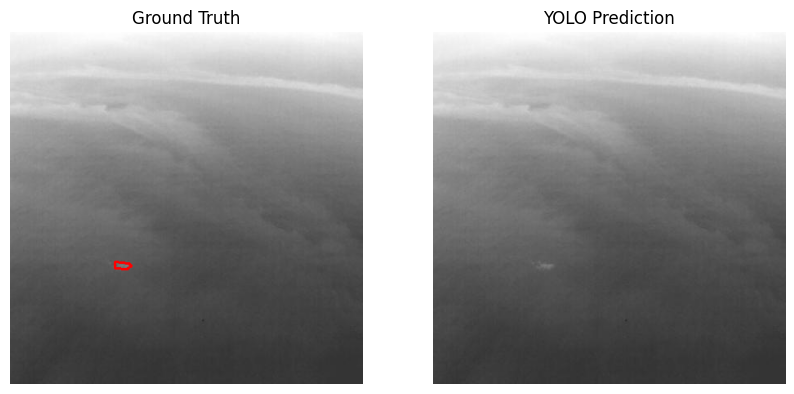

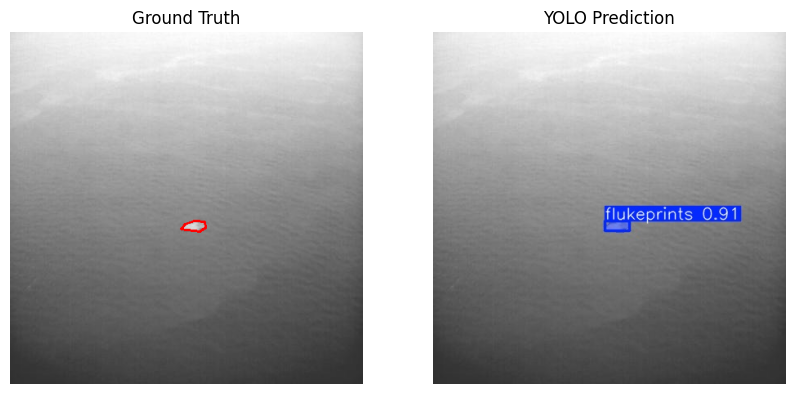

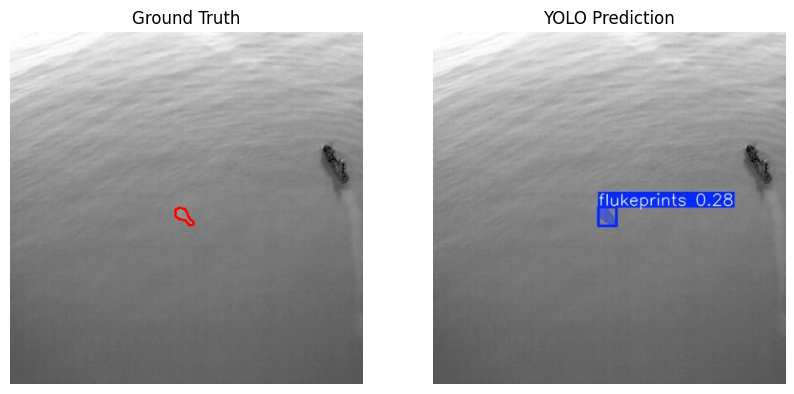

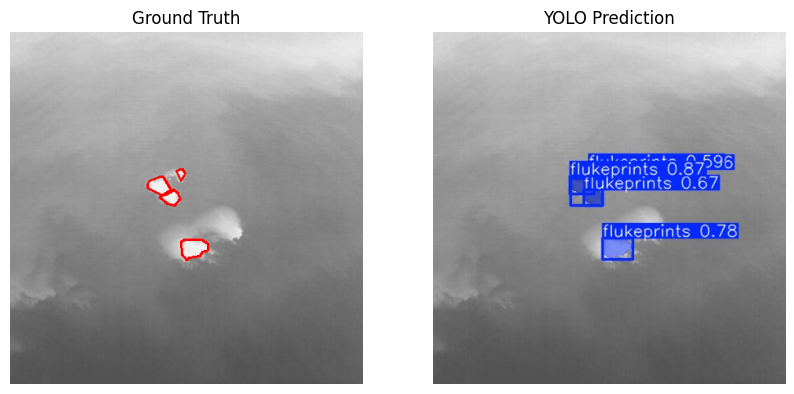

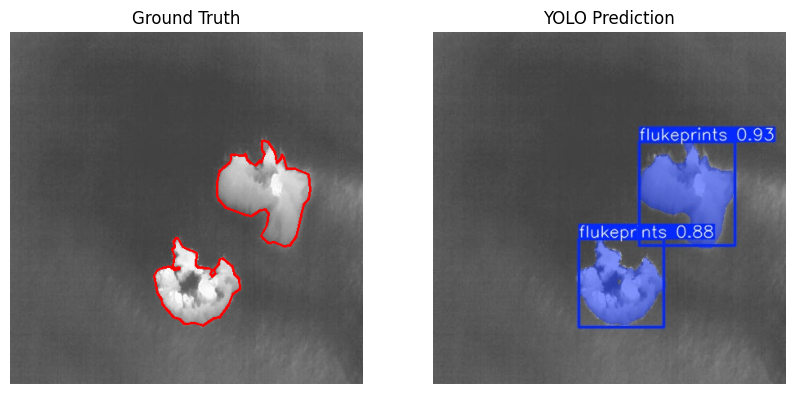

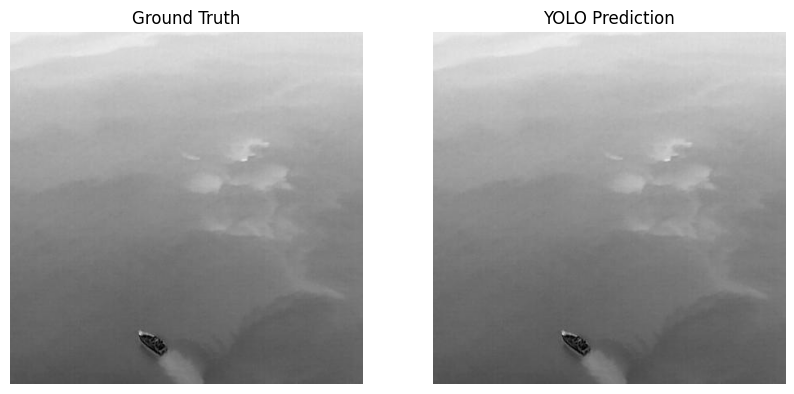

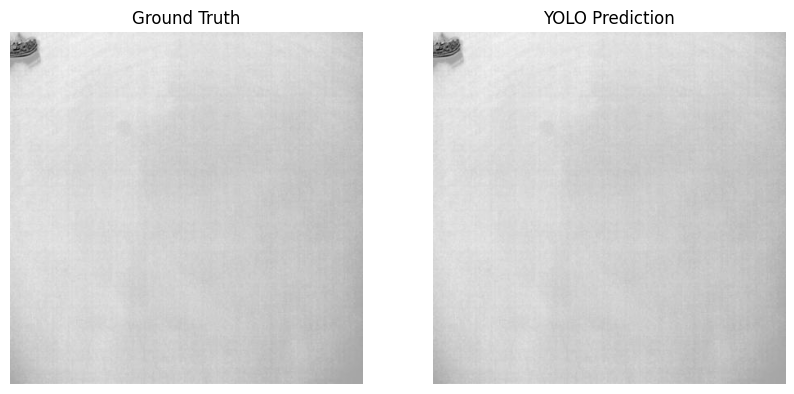

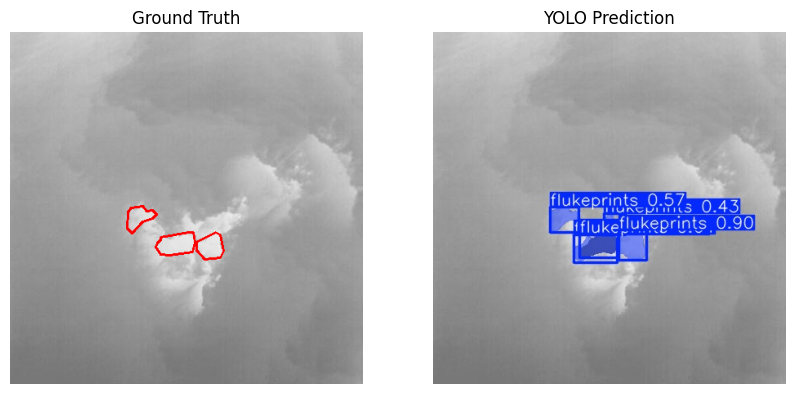

In [7]:
# Visualizing the predictions on the test set in comparison with the groundtruth

pred_path = "./runs/segment/best_baseline_test_predict"

pred_files = [f for f in os.listdir(pred_path) if f.endswith(".jpg")]

sample_images = random.sample(pred_files, min(10, len(pred_files)))

for img_name in sample_images:

    # ---------- prediction image ----------
    pred_img_path = os.path.join(pred_path, img_name)
    pred_img = cv2.imread(pred_img_path)
    pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

    # ---------- ground truth image ----------
    original_img_path = os.path.join(images_path, img_name)
    label_path = os.path.join(labels_path, img_name.replace(".jpg",".txt"))

    gt_img = cv2.imread(original_img_path)
    gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)

    gt_img = draw_ground_truth(gt_img, label_path)

    # ---------- display ----------
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(gt_img)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(pred_img)
    plt.title("YOLO Prediction")
    plt.axis("off")

    plt.show()

### Think about ameliorations on the predictions

We see that there are some overlap, this can be improved by reducing the value of the iou parameter. It was set by default at 0.7, meaning a toleration of 70% overlap... which seems to high in our case

In [8]:
metrics_test = best_baseline.val(
    data="./F_Binary_Dataset/data.yaml",
    split="test",
    iou=0.3,
    verbose=True,
    plots=True
)

p  = metrics_test.seg.p.mean()
r  = metrics_test.seg.r.mean()
f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

print("\n" + "=" * 60)
print("BASELINE Yolov8n-seg Metrics on Test Set (IoU=0.3):")
print("=" * 60)
print(f"mAP50        (Box):  {metrics_test.box.map50:.4f}")
print(f"mAP50-95     (Box):  {metrics_test.box.map:.4f}")
print(f"mAP50        (Mask): {metrics_test.seg.map50:.4f}")
print(f"mAP50-95     (Mask): {metrics_test.seg.map:.4f}")
print(f"Recall       (Mask): {r:.4f}")
print(f"Precision    (Mask): {p:.4f}")
print(f"F1           (Mask): {f1:.4f}")
print("=" * 60)

Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1026.6±268.6 MB/s, size: 13.3 KB)
val: Scanning /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/labels.cache... 95 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 95/95 16.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 3.3it/s 1.8s0.4s
                   all         95        297      0.837       0.78      0.835      0.619      0.837       0.78      0.839       0.55
Speed: 2.8ms preprocess, 3.0ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to /home/floreM/FlukePrint_YOLO/Gihub_final/runs/segment/val

BASELINE Yolov8n-seg Metrics on Test Set (IoU=0.3):
mAP50        (Box):  0.8350
mAP50-95     (Box

We can see some improvement but not full correction of the problem !
Let's try with a lower confidence threshold to increase recall.

In [9]:
metrics_test = best_baseline.val(
    data="./F_Binary_Dataset/data.yaml",
    split="test",
    conf=0.1,
    verbose=True,
    plots=True
)

p  = metrics_test.seg.p.mean()
r  = metrics_test.seg.r.mean()
f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

print("\n" + "=" * 60)
print("BASELINE Yolov8n-seg Metrics on Test Set (Conf=0.1):")
print("=" * 60)
print(f"mAP50        (Box):  {metrics_test.box.map50:.4f}")
print(f"mAP50-95     (Box):  {metrics_test.box.map:.4f}")
print(f"mAP50        (Mask): {metrics_test.seg.map50:.4f}")
print(f"mAP50-95     (Mask): {metrics_test.seg.map:.4f}")
print(f"Recall       (Mask): {r:.4f}")
print(f"Precision    (Mask): {p:.4f}")
print(f"F1           (Mask): {f1:.4f}")
print("=" * 60)

Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 969.5±70.6 MB/s, size: 12.0 KB)
val: Scanning /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/labels.cache... 95 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 95/95 33.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 3.4it/s 1.7s0.3s
                   all         95        297      0.822      0.778       0.84      0.647      0.822      0.778      0.843      0.576
Speed: 3.1ms preprocess, 1.4ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to /home/floreM/FlukePrint_YOLO/Gihub_final/runs/segment/val

BASELINE Yolov8n-seg Metrics on Test Set (Conf=0.1):
mAP50        (Box):  0.8398
mAP50-95     (Box):  0.6472
mAP50        (Mask): 0.8435
mAP50-95     (Mask): 0.5762
Recall       (Mask): 

Choosing the best iou and conf value

In [13]:
TEST_IMAGES = 95  # Number of images in the test set

settings = [
    {"conf": 0.25, "iou": 0.70, "note": "Default YOLOv8"},
    {"conf": 0.25, "iou": 0.30, "note": "Default Conf + Aggressive NMS"},
    {"conf": 0.10, "iou": 0.70, "note": "Low Conf + Default NMS"},
    {"conf": 0.10, "iou": 0.30, "note": "Low Conf + Aggressive NMS"},
]

print("=" * 60)
print("Testing Inference Hyperparameters on Test Set")
print("=" * 60)

results = []
for i, s in enumerate(settings, 1):
    metrics = best_baseline.val(
        data="./F_Binary_Dataset/data.yaml",
        split="test",
        conf=s["conf"],
        iou=s["iou"],
        verbose=False,
        plots=False
    )
    recall    = metrics.seg.r[0]
    precision = metrics.seg.p[0]
    f1        = 2 * (precision * recall) / (precision + recall + 1e-8)
    fn        = int(TEST_IMAGES * (1 - recall))

    results.append({
        "#"        : i,
        "Setting"  : s["note"],
        "Conf"     : s["conf"],
        "NMS IoU"  : s["iou"],
        "Recall"   : round(recall, 4),
        "Precision": round(precision, 4),
        "F1"       : round(f1, 4),
        "Est. FN"  : fn,
    })
    print(f"[{i}/{len(settings)}] {s['note']:<35} | Recall={recall:.4f}  Precision={precision:.4f}  F1={f1:.4f}  Est.FN={fn}")

df = pd.DataFrame(results)

print("\n")
print(df.to_string(index=False))

best_recall = df.loc[df["Recall"].idxmax(), "Setting"]
best_f1     = df.loc[df["F1"].idxmax(), "Setting"]
print(f"\n  Best Recall : {best_recall}")
print(f"  Best F1     : {best_f1}")

Testing Inference Hyperparameters on Test Set
Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 994.6±182.5 MB/s, size: 12.5 KB)
val: Scanning /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/labels.cache... 95 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 95/95 49.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 12.6it/s 0.5s0.1s
                   all         95        297      0.822      0.778      0.833      0.652      0.822      0.778      0.838      0.583
Speed: 1.0ms preprocess, 0.7ms inference, 0.0ms loss, 0.6ms postprocess per image
[1/4] Default YOLOv8                      | Recall=0.7778  Precision=0.8224  F1=0.7995  Est.FN=21
Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
val: Fast image ac

In [14]:
metrics_test = best_baseline.val(
    data="./F_Binary_Dataset/data.yaml",
    split="test",
    conf=0.25,
    iou=0.3,
    verbose=True,
    plots=True
)

p  = metrics_test.seg.p.mean()
r  = metrics_test.seg.r.mean()
f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

print("\n" + "=" * 60)
print("BASELINE Yolov8n-seg Metrics on Test Set (Conf=0.25, IoU=0.3):")
print("=" * 60)
print(f"mAP50        (Box):  {metrics_test.box.map50:.4f}")
print(f"mAP50-95     (Box):  {metrics_test.box.map:.4f}")
print(f"mAP50        (Mask): {metrics_test.seg.map50:.4f}")
print(f"mAP50-95     (Mask): {metrics_test.seg.map:.4f}")
print(f"Recall       (Mask): {r:.4f}")
print(f"Precision    (Mask): {p:.4f}")
print(f"F1           (Mask): {f1:.4f}")
print("=" * 60)

Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 324.7±144.4 MB/s, size: 13.2 KB)
val: Scanning /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/labels.cache... 95 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 95/95 33.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 3.3it/s 1.8s0.4s
                   all         95        297      0.837       0.78      0.839      0.656      0.837       0.78      0.842      0.587
Speed: 3.0ms preprocess, 1.9ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /home/floreM/FlukePrint_YOLO/Gihub_final/runs/segment/val

BASELINE Yolov8n-seg Metrics on Test Set (Conf=0.25, IoU=0.3):
mAP50        (Box):  0.8391
mAP50-95     (Box):  0.6560
mAP50        (Mask): 0.8422
mAP50-95     (Mask): 0.5867
Recall    

### Second training 

Changes are:
- correct the image size from 640 to the right one 432
- more epoch as the loss functions still decrease : from 50 to 100
- more batch : no
- qualitatively adapt augmentation parameters : cf test_tuned.yaml
- model : use yolo26n-seg !

In [18]:
model_26 = YOLO("yolo26n-seg.pt") 

In [20]:
# train the model on our dataset
results = model_26.train(
    cfg="./F_Binary_Dataset/test_tuned.yaml",
    name="test_yolo26n"
)

New https://pypi.org/project/ultralytics/8.4.59 available 😃 Update with 'pip install -U ultralytics'
WARNING ⚠️ 'crop_fraction' is deprecated and will be removed in the future.
Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=./F_Binary_Dataset/test_tuned.yaml, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./F_Binary_Dataset/data.yaml, degrees=360.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.0, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=432, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=

In [21]:
best_model_26 = YOLO("./runs/segment/test_yolo26n/weights/best.pt")

metrics_test = best_model_26.val(
    data="./F_Binary_Dataset/data.yaml",
    split="test",
    conf=0.25,
    iou=0.3,
    verbose=True,
    plots=True
)

p  = metrics_test.seg.p.mean()
r  = metrics_test.seg.r.mean()
f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

print("\n" + "=" * 60)
print("Tuned Yolo26n-seg Metrics on Test Set:")
print("=" * 60)
print(f"mAP50        (Box):  {metrics_test.box.map50:.4f}")
print(f"mAP50-95     (Box):  {metrics_test.box.map:.4f}")
print(f"mAP50        (Mask): {metrics_test.seg.map50:.4f}")
print(f"mAP50-95     (Mask): {metrics_test.seg.map:.4f}")
print(f"Recall       (Mask): {r:.4f}")
print(f"Precision    (Mask): {p:.4f}")
print(f"F1           (Mask): {f1:.4f}")
print("=" * 60)

Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,079 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 870.7±199.0 MB/s, size: 11.3 KB)
val: Scanning /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/labels.cache... 95 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 95/95 26.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 3.9it/s 1.5s0.3s
                   all         95        297      0.752      0.653      0.715      0.549      0.744      0.646      0.714      0.476
Speed: 1.5ms preprocess, 4.4ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /home/floreM/FlukePrint_YOLO/Gihub_final/runs/segment/val

Tuned Yolo26n-seg Metrics on Test Set:
mAP50        (Box):  0.7152
mAP50-95     (Box):  0.5489
mAP

In [22]:
predictions = best_model_26.predict(
    source="./F_Binary_Dataset/test/images",
    save=True,
    conf=0.25,
    iou=0.3
)


image 1/95 /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/images/video_001_event3_A001_500_t-00000s_01_jpg.rf.a1c72ee891d1f439c9979daf20d664d7.jpg: 448x448 (no detections), 7.0ms
image 2/95 /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/images/video_001_event3_A001_620_t-00120s_jpg.rf.a4f767ad4c3564bf2b0793cccda1c348.jpg: 448x448 (no detections), 7.1ms
image 3/95 /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/images/video_026_event1_A015_500_t-00000s_04_jpg.rf.0b35c4347090497620246541fc73f63e.jpg: 448x448 1 flukeprints, 6.9ms


image 4/95 /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/images/video_026_event1_A015_500_t-00000s_05_jpg.rf.dc896da39b0168755ae64bf12c7c5366.jpg: 448x448 1 flukeprints, 7.8ms
image 5/95 /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/images/video_030_event10_A018_500_t-00000s_01_jpg.rf.bfcedb7fff2a590cd37ec2ea512900f0.jpg: 448x448 5 flukeprintss, 7.0ms
image 6/95 /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/images/video_030_event10_A018_510_t-00010s_jpg.rf.82bc2f94a461c205650287a25ae78e06.jpg: 448x448 4 flukeprintss, 6.9ms
image 7/95 /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/images/video_030_event11_A018_500_t-00000s_05_jpg.rf.984a230fb5d3893f8b4de3b5f5632650.jpg: 448x448 1 flukeprints, 7.0ms
image 8/95 /home/floreM/FlukePrint_YOLO/Gihub_final/F_Binary_Dataset/test/images/video_030_event11_A018_510_t-00010s_jpg.rf.1c9eb68fa0da3655f4a285c2774afb89.jpg: 448x448 1 flukeprints, 7.1ms
image 9/95 /home/floreM/FlukePrint_

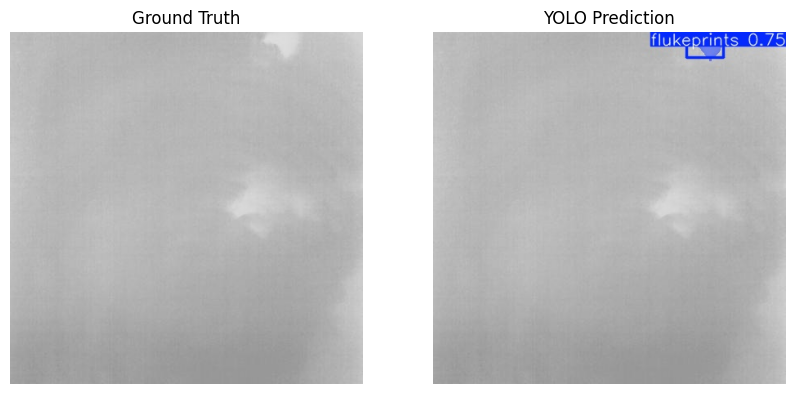

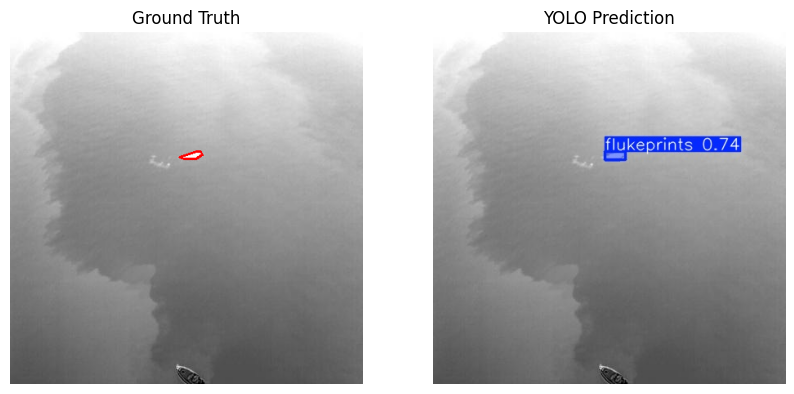

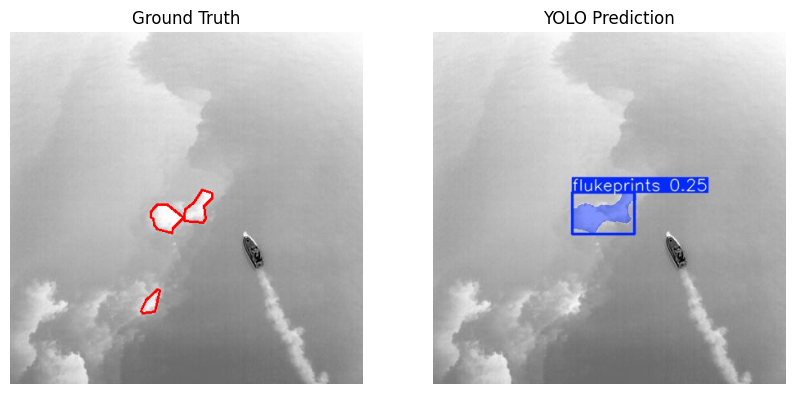

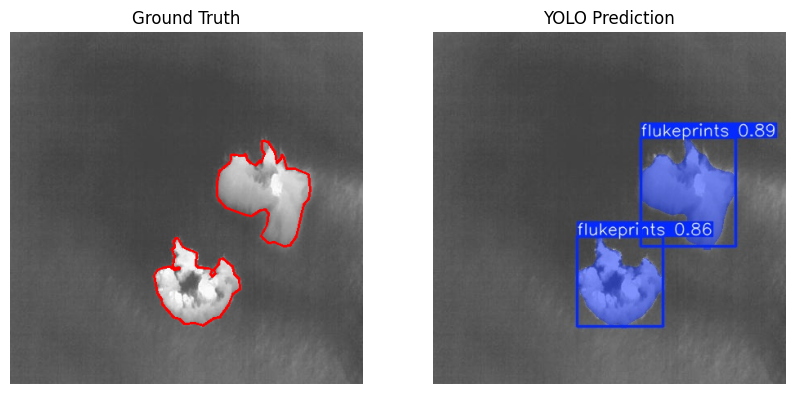

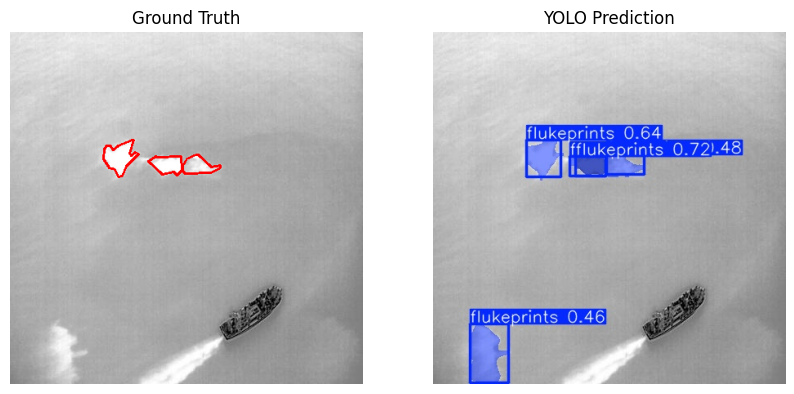

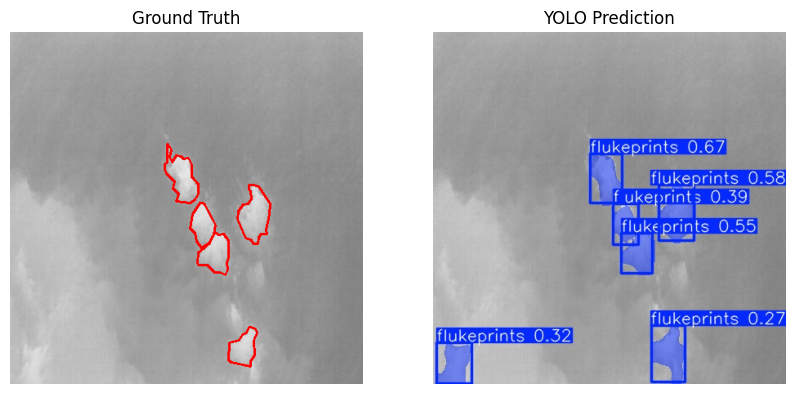

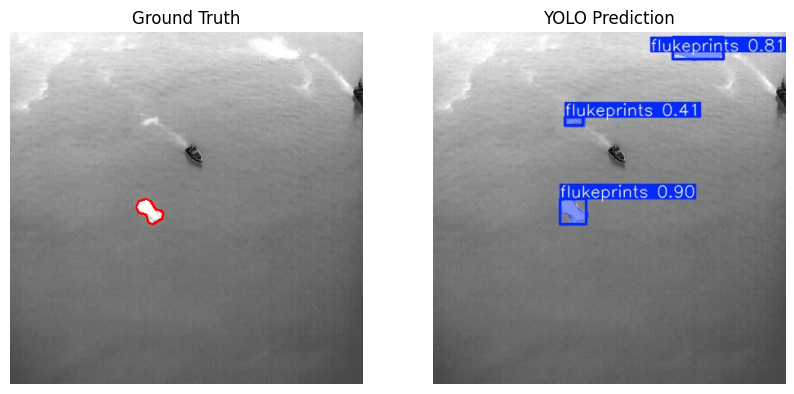

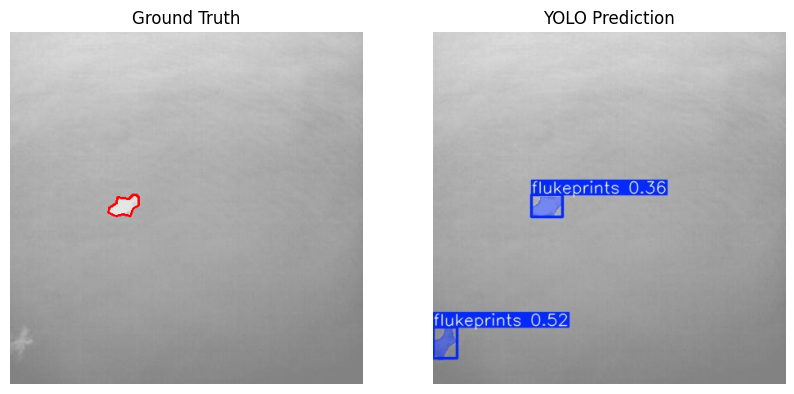

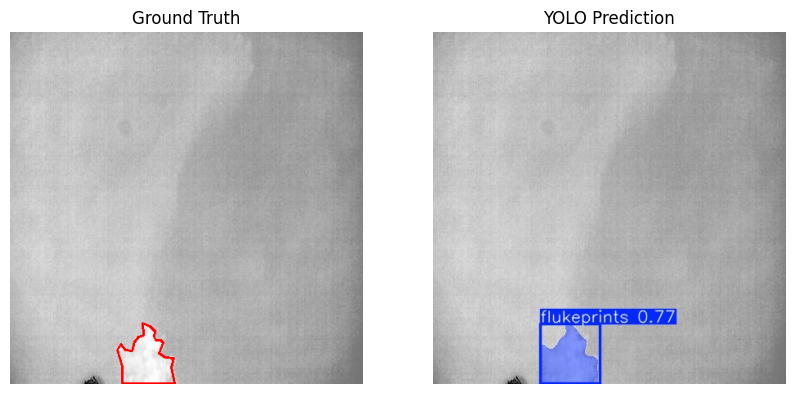

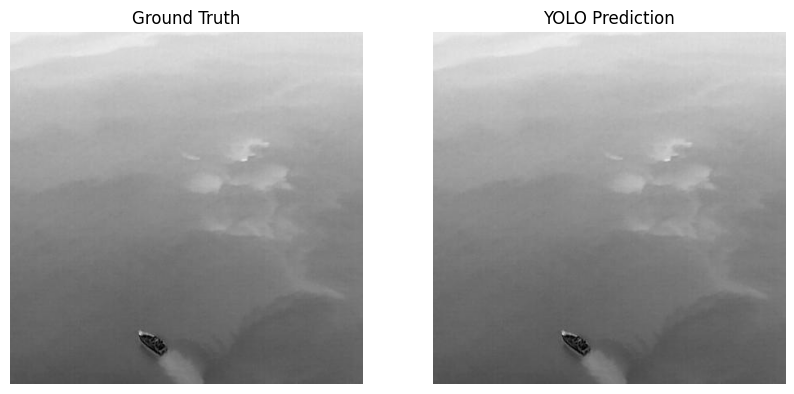

In [23]:
# Visualizing the predictions on the test set in comparison with the groundtruth

pred_path = "./runs/segment/test_yolo26n_predict"

pred_files = [f for f in os.listdir(pred_path) if f.endswith(".jpg")]

sample_images = random.sample(pred_files, min(10, len(pred_files)))

for img_name in sample_images:

    # ---------- prediction image ----------
    pred_img_path = os.path.join(pred_path, img_name)
    pred_img = cv2.imread(pred_img_path)
    pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

    # ---------- ground truth image ----------
    original_img_path = os.path.join(images_path, img_name)
    label_path = os.path.join(labels_path, img_name.replace(".jpg",".txt"))

    gt_img = cv2.imread(original_img_path)
    gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)

    gt_img = draw_ground_truth(gt_img, label_path)

    # ---------- display ----------
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(gt_img)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(pred_img)
    plt.title("YOLO Prediction")
    plt.axis("off")

    plt.show()

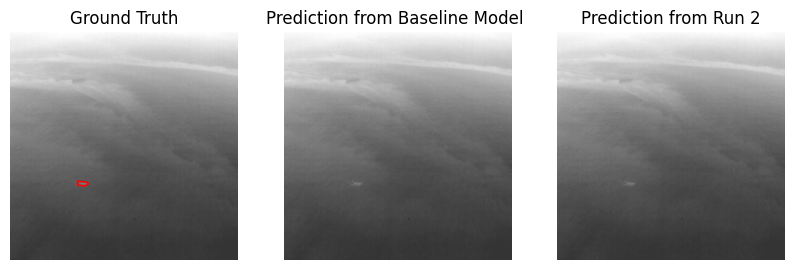

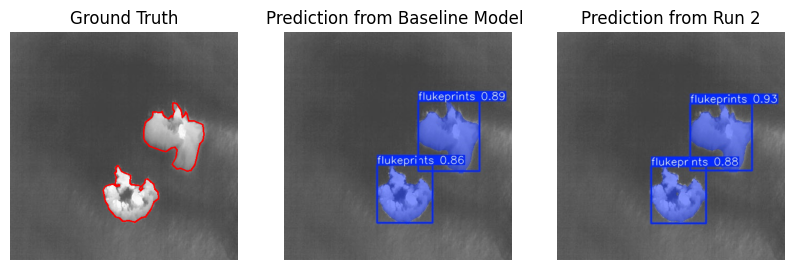

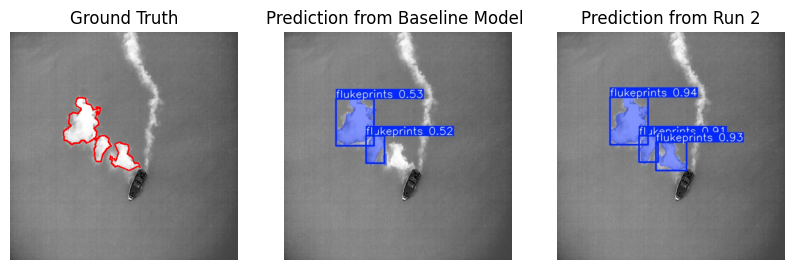

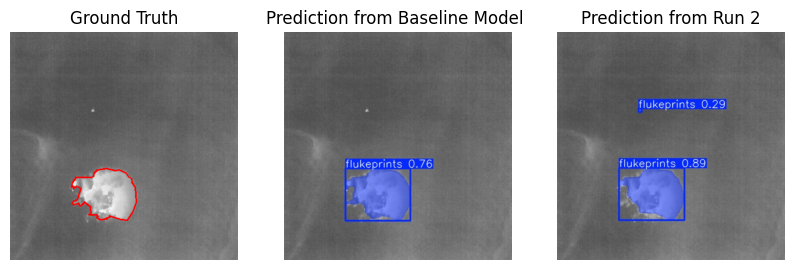

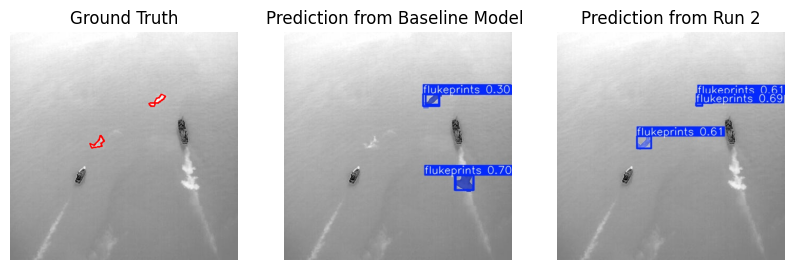

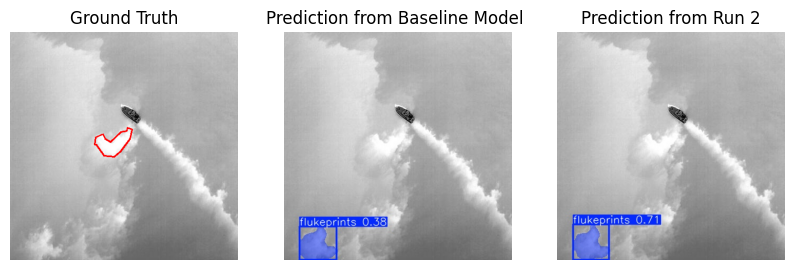

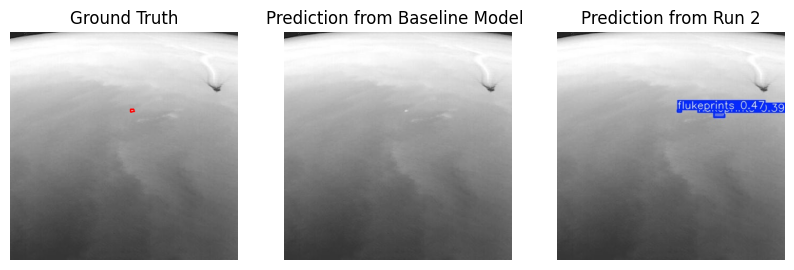

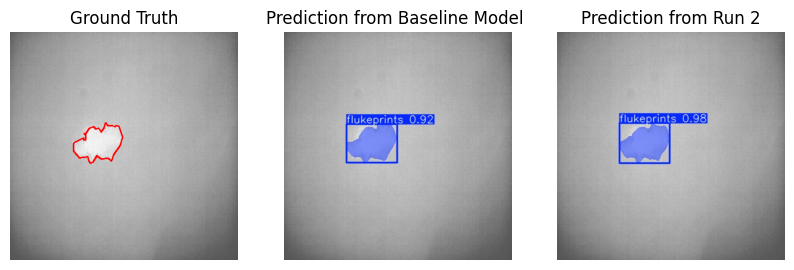

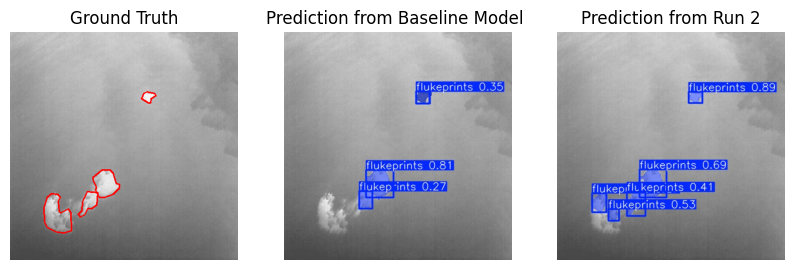

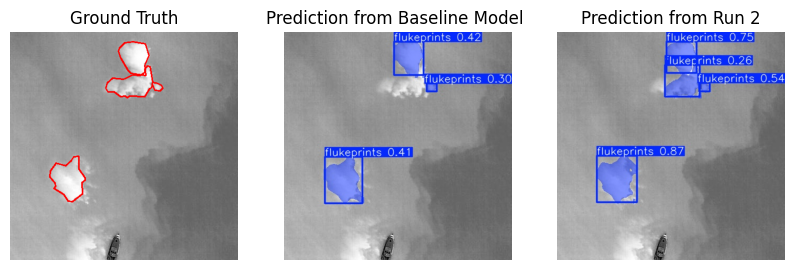

In [24]:
# Visualizing of this new predictions on the test set - to see if less overlap with iou=0.3 

pred2_path = "./runs/segment/best_baseline_test_predict"
pred2_files = [f for f in os.listdir(pred2_path) if f.endswith(".jpg")]
sample_images = random.sample(pred2_files, min(10, len(pred2_files)))

pred1_path = "./runs/segment/test_yolo26n_predict"

for img_name in sample_images:

    # ---------- prediction 2 ----------
    pred2_img_path = os.path.join(pred2_path, img_name)
    pred2_img = cv2.imread(pred2_img_path)
    pred2_img = cv2.cvtColor(pred2_img, cv2.COLOR_BGR2RGB)

    # ---------- prediction 1 ----------
    pred1_img_path = os.path.join(pred1_path, img_name)
    pred1_img = cv2.imread(pred1_img_path)
    pred1_img = cv2.cvtColor(pred1_img, cv2.COLOR_BGR2RGB)

    # ---------- ground truth image ----------
    original_img_path = os.path.join(images_path, img_name)
    label_path = os.path.join(labels_path, img_name.replace(".jpg",".txt"))

    gt_img = cv2.imread(original_img_path)
    gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)

    gt_img = draw_ground_truth(gt_img, label_path)

    # ---------- display ----------
    plt.figure(figsize=(10,5))

    plt.subplot(1,3,1)
    plt.imshow(gt_img)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(pred1_img)
    plt.title("Prediction from Baseline Model ")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pred2_img)
    plt.title("Prediction from Run 2")
    plt.axis("off")

    plt.show()